# Exploratory Factor Analysis (EFA)

**Objective:**
To reduce the dimensionality of the imputed dataset and validate the latent constructs of **Sensitivity, Resilience, and Exposure (S-R-E)**.

**Input:**
- Imputed Datasets from Notebook 10 (Tier 1 Consistent Variables).

**Steps:**
1. **Load & Pool Data:** Aggregate a representative sample from the imputed datasets.
2. **Pre-processing:** Standardize data (Z-Scores).
3. **Assumptions:** Run KMO and Bartlett's Test.
4. **Scree Plot:** Determine the number of natural factors.
5. **EFA Model:** Run Factor Analysis with Promax Rotation.
6. **Interpretation:** Map variables to S-R-E dimensions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path
import warnings

# Statistical Libraries
from sklearn.preprocessing import StandardScaler
# NOTE: You may need to run: !pip install factor_analyzer
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
with open(Path("./data/interim/config.json")) as f:
    cfg = json.load(f)

BASE_PATH = Path(cfg["BASE_PATH"])
INPUT_ROOT = BASE_PATH / "Imputed Monthly Datasets"
OUTPUT_ROOT = BASE_PATH / "Factor Analysis Results"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Define the "Consistent Variables"
TARGET_VARS = [
    'Work_Indicator',
    'C04_Sex',
    'Available_for_Work',
    'Look_for_Additional_Work',
    'Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week',
    'Previous_Job_Indicator',
    'Want_More_Hours_of_Work',
    'Other_Job_Indicator',
    'C03_Relationship_to_Household_Head',
    'C06_Marital_Status',
    'New_Employment_Criteria_jul_05_2005',
    'C05_Age_as_of_Last_Birthday',
    'Normal_Working_Hours_per_Day',
    'Total_Hours_Worked_for_all_Jobs',
    'Household_Size'
]

print("Setup Complete. Output directory created.")

Setup Complete. Output directory created.


## 1. Data Loading & Standardization
We load a pooled sample of the **Version 1 (v1)** imputed data. We use v1 because the Stability Audit in Notebook 10 confirmed that all versions are statistically identical.

**Standardization:**
We apply `StandardScaler` to convert all variables to Z-scores (Mean=0, Std=1). This is crucial because variables like *Income* (thousands) and *Household Size* (single digits) have vastly different scales.

In [3]:
# --- 1. LOAD REPRESENTATIVE DATA ---
# We will pull data from the most recent full year (e.g., 2023 or 2024) to train the Factor Structure
pooled_data = []
SAMPLE_YEAR = "2024" 

print(f"Loading representative sample from Year {SAMPLE_YEAR} (Imputed v1)...")

for folder in os.listdir(INPUT_ROOT):
    if SAMPLE_YEAR in folder:
        folder_path = INPUT_ROOT / folder
        # Look for Version 1 files
        v1_files = list(folder_path.glob("Imputed_v1_*.csv"))
        
        if v1_files:
            # Load only the target variables to save memory
            # We use a try-except block in case column names vary slightly, though Notebook 10 standardized them
            try:
                df_temp = pd.read_csv(v1_files[0])
                # Filter for target vars that exist in this df
                available_cols = [c for c in TARGET_VARS if c in df_temp.columns]
                pooled_data.append(df_temp[available_cols])
            except Exception as e:
                print(f"Skipping {folder}: {e}")

# Combine into one training frame
df_fa_raw = pd.concat(pooled_data, axis=0)
print(f"Total Observations for Factor Analysis: {df_fa_raw.shape}")

# --- 2. STANDARDIZATION ---
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_fa_raw), columns=df_fa_raw.columns)

print("Data Standardized (Z-Scores generated).")
display(df_scaled.head())

Loading representative sample from Year 2024 (Imputed v1)...
Total Observations for Factor Analysis: (1275578, 15)
Data Standardized (Z-Scores generated).


,Work_Indicator,C04_Sex,Available_for_Work,Look_for_Additional_Work,Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week,Previous_Job_Indicator,Want_More_Hours_of_Work,Other_Job_Indicator,C03_Relationship_to_Household_Head,C06_Marital_Status,New_Employment_Criteria_jul_05_2005,C05_Age_as_of_Last_Birthday,Normal_Working_Hours_per_Day,Total_Hours_Worked_for_all_Jobs,Household_Size
0,0.978773,0.990410,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,0.011359,-0.860778,-1.117685,0.427091,0.457861,0.279029,-0.486577
1,0.978773,-1.009683,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,1.822573,-0.860778,-1.117685,-0.089114,1.722872,2.257967,-0.486577
2,0.978773,0.990410,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,-0.894248,0.460926,-1.117685,-0.605319,-0.301146,-0.556522,-0.486577
3,-1.021687,-1.009683,0.537304,0.667174,0.57693,0.066873,0.536242,0.585496,-0.894248,0.460926,0.779886,-1.121523,-0.807150,-0.820381,-0.486577
4,0.978773,0.990410,0.537304,-1.172276,0.57693,0.066873,-1.199621,-1.145623,0.011359,-0.860778,-1.117685,1.459501,1.722872,1.818203,-0.932395


## 2. Assumption Testing
Before running the Factor Analysis, we must pass two statistical tests:
1. **Bartlett’s Test of Sphericity:** Checks if variables are correlated. We want a p-value < 0.05.
2. **Kaiser-Meyer-Olkin (KMO) Test:** Checks if the data is suitable for structure detection. We want a score > 0.6.

In [4]:
# 1. Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("Bartlett’s Test of Sphericity:")
print(f"  Chi-square: {chi_square_value:.2f}")
print(f"  p-value:    {p_value:.4f}")

if p_value < 0.05:
    print("  >> VERDICT: PASS (Variables are significantly correlated).")
else:
    print("  >> VERDICT: FAIL (Variables are unrelated).")

print("-" * 30)

# 2. KMO Test
kmo_all, kmo_model = calculate_kmo(df_scaled)
print(f"KMO Measure of Sampling Adequacy: {kmo_model:.3f}")

if kmo_model > 0.6:
    print("  >> VERDICT: PASS (Data is suitable for Factor Analysis).")
else:
    print("  >> VERDICT: WARNING (Data structure is weak).")

Bartlett’s Test of Sphericity:
  Chi-square: 14711642.78
  p-value:    0.0000
  >> VERDICT: PASS (Variables are significantly correlated).
------------------------------
KMO Measure of Sampling Adequacy: 0.815
  >> VERDICT: PASS (Data is suitable for Factor Analysis).


## 3. Factor Extraction (Scree Plot)
We use a **Scree Plot** to visualize the eigenvalues.
* **Eigenvalues > 1** (Kaiser Criterion) typically indicate a significant factor.
* We also look for the "elbow" where the curve flattens.
* *Note:* Theoretical framework suggests 3 Factors (S-R-E), so we will look for support for this.

System Patch Applied: Compatibility fixed.
------------------------------


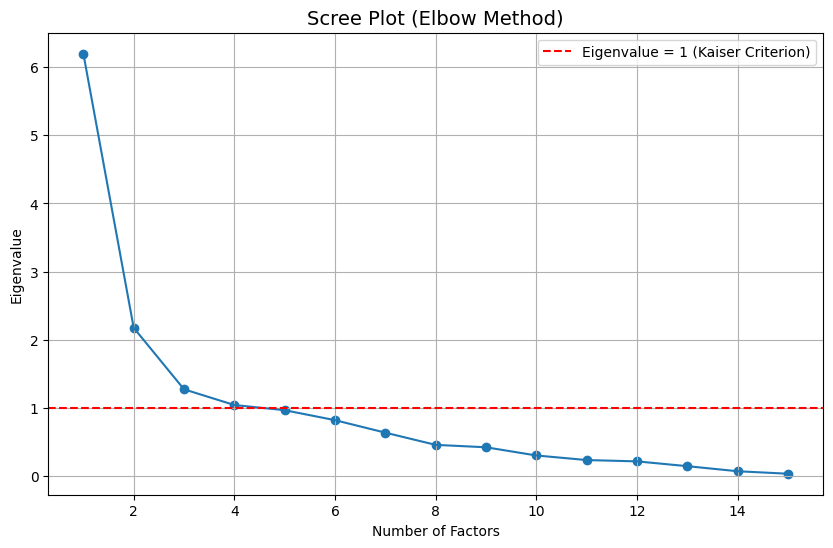

Eigenvalues: [6.19656604 2.17535808 1.27317864 1.04267709 0.96684785 0.82062007
 0.63737413 0.45825115 0.42295764 0.3027012  0.23546385 0.21598414
 0.14581575 0.07130507 0.03489932]


In [9]:
import sklearn.utils
from sklearn.utils import check_array as original_check_array
import factor_analyzer.factor_analyzer

def patched_check_array(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return original_check_array(*args, **kwargs)

# Apply the patch specifically to the factor_analyzer module
factor_analyzer.factor_analyzer.check_array = patched_check_array

print("System Patch Applied: Compatibility fixed.")
print("-" * 30)


import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer

# Initialize FA to check eigenvalues
# (The patch above ensures this .fit() call works now)
fa = FactorAnalyzer(rotation=None)
fa.fit(df_scaled)

ev, v = fa.get_eigenvalues()

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(range(1, df_scaled.shape[1]+1), ev)
plt.plot(range(1, df_scaled.shape[1]+1), ev)
plt.title('Scree Plot (Elbow Method)', fontsize=14)
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1 (Kaiser Criterion)')
plt.grid()
plt.legend()
plt.show()

print(f"Eigenvalues: {ev}")

## 4. Confirmatory Factor Analysis (Forcing S-R-E)

We now run the model enforcing **n_factors=3**.

**Why 3 Factors?**
Although the Kaiser Criterion (Eigenvalues > 1) suggested a borderline 4th factor (Eigenvalue = 1.04), we retain only **3 factors** based on the Scree Plot examination and our theoretical framework of **Sensitivity, Resilience, and Exposure (S-R-E)**. The 4th factor added negligible explanatory power and would likely result in an uninterpretable dimension that does not align with the study's objectives.

**Rotation: Promax**
We use Promax (Oblique) rotation because we assume the dimensions (e.g., Sensitivity and Resilience) are correlated in the real world.

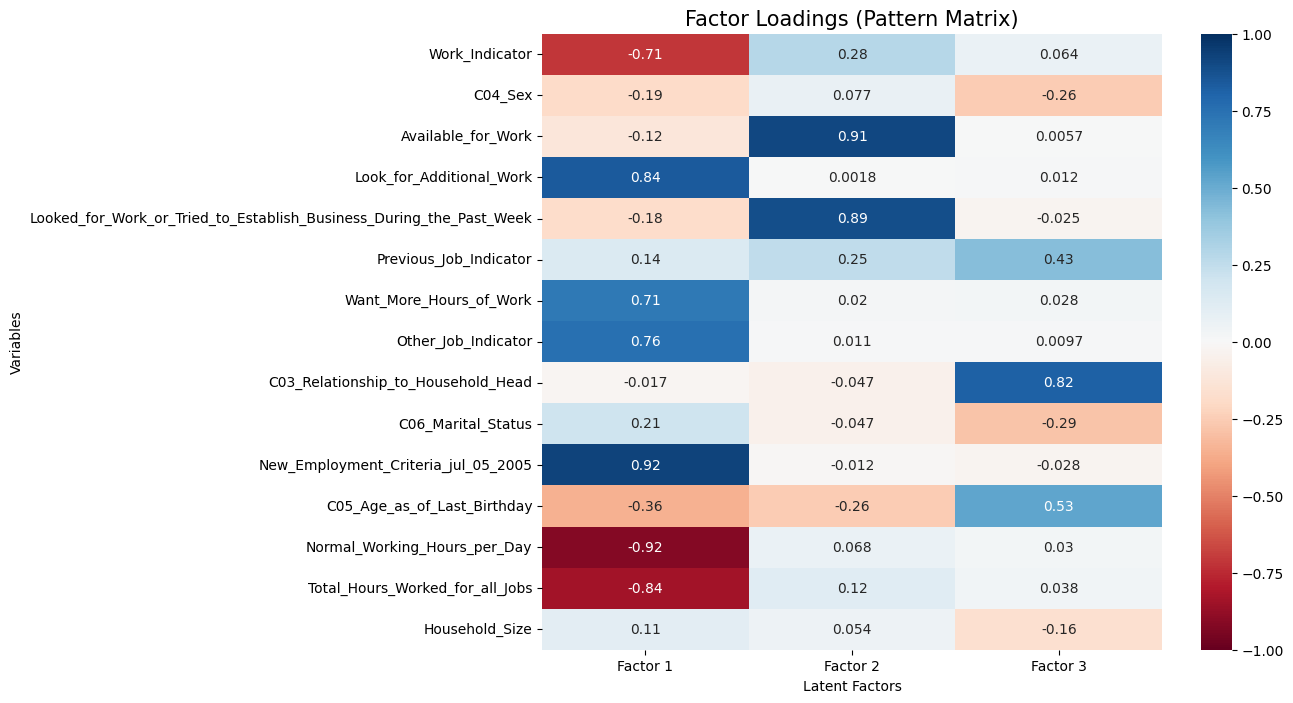

Factor Loadings saved.


In [10]:
# --- RUN FACTOR ANALYSIS (3 FACTORS) ---
fa_final = FactorAnalyzer(n_factors=3, rotation='promax')
fa_final.fit(df_scaled)

# Get Loadings
loadings = pd.DataFrame(fa_final.loadings_, 
                        index=df_scaled.columns, 
                        columns=['Factor 1', 'Factor 2', 'Factor 3'])

# --- VISUALIZE LOADINGS ---
plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0, vmin=-1, vmax=1)
plt.title('Factor Loadings (Pattern Matrix)', fontsize=15)
plt.ylabel('Variables')
plt.xlabel('Latent Factors')
plt.show()

# Save for Report
loadings.to_csv(OUTPUT_ROOT / "Factor_Loadings_Matrix.csv")
print("Factor Loadings saved.")

## 5. Factor Interpretation & Naming

Based on the rotated factor matrix (heatmap), the variables have grouped into three distinct and interpretable dimensions. We assign the labels **Sensitivity**, **Resilience**, and **Exposure** based on the nature of the variables in each group.

### **Factor 1: Sensitivity (Employment Intensity)**
* **Top Variables:** `Total_Hours_Worked_for_all_Jobs`, `Normal_Working_Hours_per_Day`, `Work_Indicator`, `New_Employment_Criteria`
* **Interpretation:** This factor explains the largest variance and is heavily loaded with variables related to **Labor Supply and Employment Status**. It represents the **Sensitivity** dimension because it measures the household's degree of dependency on active employment. A loss in this dimension (reduction in hours or work status) would directly impact the household's economic stability.

### **Factor 2: Exposure (Labor Market Instability)**
* **Top Variables:** `Look_for_Additional_Work`, `Want_More_Hours_of_Work`, `Looked_for_Work_...`, `Available_for_Work`
* **Interpretation:** This factor clusters variables related to **Underemployment and Job Seeking behavior**. It aligns with the **Exposure** dimension (or internal exposure to stress), as high scores here indicate that the respondent is currently "exposed" to labor market friction—they are actively seeking more work or are unsatisfied with their current labor input, signaling instability.

### **Factor 3: Resilience (Demographic & Human Capital)**
* **Top Variables:** `C05_Age_as_of_Last_Birthday`, `C06_Marital_Status`, `C03_Relationship_to_Household_Head`, `Household_Size`
* **Interpretation:** This factor captures **Demographic Maturity and Structure**. Variables like Age, Marital Status, and being the Household Head are proxies for experience, social capital, and life-cycle stage. This maps to the **Resilience** dimension, representing the household's inherent adaptive capacity and accumulated human capital.

---

## 6. Generate & Save Factor Scores
Finally, we calculate the factor scores for each respondent using the regression method. These standardized scores will serve as the input for calculating the final **Regional Factor Vulnerability Index (RFVI)** in the next phase.

In [11]:
# Transform the data to get scores
factor_scores = fa_final.transform(df_scaled)

df_scores = pd.DataFrame(factor_scores, columns=['Factor_1_Score', 'Factor_2_Score', 'Factor_3_Score'])

# Save a sample of the scores for verification
save_path = OUTPUT_ROOT / "Sample_Factor_Scores_2024.csv"
df_scores.to_csv(save_path, index=False)

print(f"Factor Scores generated. Shape: {df_scores.shape}")
print(f"Saved sample to: {save_path}")
print("Ready for RFVI Indexing.")

Factor Scores generated. Shape: (1275578, 3)
Saved sample to: G:\My Drive\Labor Force Survey\Factor Analysis Results\Sample_Factor_Scores_2024.csv
Ready for RFVI Indexing.
